In [22]:
from pathlib import Path

print(Path.cwd())

C:\Users\imman\OneDrive\Desktop\FYP\notebooks


# STEW EEG Dataset Exploration

This notebook explores the raw STEW (Simultaneous Task EEG Workload) dataset before applying any preprocessing.

### Objectives
- Understand the dataset structure
- Load raw EEG recordings
- Inspect EEG channels and dimensions
- Identify workload labels
- Check data quality
- Visualize raw EEG signals

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Path

The raw STEW dataset is stored separately from the notebook.

Each recording is named according to:

- `subXX_hi` → High workload
- `subXX_lo` → Low workload

In [24]:
from pathlib import Path

dataset_path = Path("../STEW Dataset")

print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())

Dataset path: ..\STEW Dataset
Dataset exists: True


In [25]:
files = sorted(dataset_path.iterdir())

print("Total files:", len(files))

for file in files[:10]:
    print(file.name)

Total files: 97
ratings.txt
sub01_hi.txt
sub01_lo.txt
sub02_hi.txt
sub02_lo.txt
sub03_hi.txt
sub03_lo.txt
sub04_hi.txt
sub04_lo.txt
sub05_hi.txt


In [26]:
eeg_files = [
    f for f in dataset_path.iterdir()
    if f.name.startswith("sub")
]

ratings_file = dataset_path / "ratings"

print("EEG recordings:", len(eeg_files))
print("Ratings file exists:", ratings_file.exists())

EEG recordings: 96
Ratings file exists: False


In [27]:
hi_files = sorted([f for f in eeg_files if "_hi" in f.name])
lo_files = sorted([f for f in eeg_files if "_lo" in f.name])

print("High workload recordings:", len(hi_files))
print("Low workload recordings:", len(lo_files))

High workload recordings: 48
Low workload recordings: 48


In [28]:
sample_file = dataset_path / "sub01_hi"

print("File:", sample_file)
print("Exists:", sample_file.exists())

File: ..\STEW Dataset\sub01_hi
Exists: False


In [29]:
from pathlib import Path

current = Path.cwd()

print("Current folder:")
print(current)

print("\nFolders/files one level above:")
for item in current.parent.iterdir():
    print(item.name)

Current folder:
C:\Users\imman\OneDrive\Desktop\FYP\notebooks

Folders/files one level above:
.git
.gitignore
feature_extraction
notebooks
preprocessing
README.md
STEW Dataset


In [30]:


for file in sorted(dataset_path.iterdir())[:15]:
    print(file.name)

ratings.txt
sub01_hi.txt
sub01_lo.txt
sub02_hi.txt
sub02_lo.txt
sub03_hi.txt
sub03_lo.txt
sub04_hi.txt
sub04_lo.txt
sub05_hi.txt
sub05_lo.txt
sub06_hi.txt
sub06_lo.txt
sub07_hi.txt
sub07_lo.txt


In [31]:
sample_file = dataset_path / "sub01_hi.txt"

print("File:", sample_file)
print("Exists:", sample_file.exists())

File: ..\STEW Dataset\sub01_hi.txt
Exists: True


In [32]:
with open(sample_file, "r") as f:
    for i in range(5):
        print(f.readline().strip())

4.5846200e+03   3.9020500e+03   4.5717900e+03   4.5892300e+03   4.1246200e+03   3.8251300e+03   4.1528200e+03   4.5794900e+03   4.6907700e+03   4.2600000e+03   4.0271800e+03   4.3851300e+03   4.4805100e+03   4.2307700e+03
4.5841000e+03   3.8959000e+03   4.5748700e+03   4.5676900e+03   4.1241000e+03   3.8271800e+03   4.1579500e+03   4.5851300e+03   4.6953800e+03   4.2682100e+03   4.0343600e+03   4.3800000e+03   4.5015400e+03   4.1974400e+03
4.5743600e+03   3.8938500e+03   4.5769200e+03   4.5728200e+03   4.1235900e+03   3.8292300e+03   4.1651300e+03   4.5902600e+03   4.7025600e+03   4.2815400e+03   4.0307700e+03   4.3666700e+03   4.5210300e+03   4.1764100e+03
4.5738500e+03   3.9061500e+03   4.5728200e+03   4.6123100e+03   4.1379500e+03   3.8307700e+03   4.1671800e+03   4.5969200e+03   4.7061500e+03   4.2856400e+03   4.0384600e+03   4.3764100e+03   4.5189700e+03   4.2071800e+03
4.5835900e+03   3.9112800e+03   4.5702600e+03   4.6210300e+03   4.1507700e+03   3.8338500e+03   4.1661500e+03   

In [33]:
import numpy as np

raw_data = np.loadtxt(sample_file)

print("Shape of raw data:", raw_data.shape)
print("Number of samples:", raw_data.shape[0])
print("Number of columns:", raw_data.shape[1])

Shape of raw data: (19200, 14)
Number of samples: 19200
Number of columns: 14


In [34]:
print("\nFirst 5 rows:")
print(raw_data[:5])

print("\nFirst row:")
print(raw_data[0])

print("\nData type:", raw_data.dtype)


First 5 rows:
[[4584.62 3902.05 4571.79 4589.23 4124.62 3825.13 4152.82 4579.49 4690.77
  4260.   4027.18 4385.13 4480.51 4230.77]
 [4584.1  3895.9  4574.87 4567.69 4124.1  3827.18 4157.95 4585.13 4695.38
  4268.21 4034.36 4380.   4501.54 4197.44]
 [4574.36 3893.85 4576.92 4572.82 4123.59 3829.23 4165.13 4590.26 4702.56
  4281.54 4030.77 4366.67 4521.03 4176.41]
 [4573.85 3906.15 4572.82 4612.31 4137.95 3830.77 4167.18 4596.92 4706.15
  4285.64 4038.46 4376.41 4518.97 4207.18]
 [4583.59 3911.28 4570.26 4621.03 4150.77 3833.85 4166.15 4597.44 4705.13
  4282.05 4051.79 4387.18 4520.51 4220.  ]]

First row:
[4584.62 3902.05 4571.79 4589.23 4124.62 3825.13 4152.82 4579.49 4690.77
 4260.   4027.18 4385.13 4480.51 4230.77]

Data type: float64


In [35]:
channel_names = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

print("Number of channels:", len(channel_names))

for i, channel in enumerate(channel_names):
    print(f"Column {i}: {channel}")

Number of channels: 14
Column 0: AF3
Column 1: F7
Column 2: F3
Column 3: FC5
Column 4: T7
Column 5: P7
Column 6: O1
Column 7: O2
Column 8: P8
Column 9: T8
Column 10: FC6
Column 11: F4
Column 12: F8
Column 13: AF4


In [36]:
print("Missing values:", np.isnan(raw_data).sum())
print("Infinite values:", np.isinf(raw_data).sum())

print("\nMinimum value:", raw_data.min())
print("Maximum value:", raw_data.max())
print("Mean:", raw_data.mean())
print("Standard deviation:", raw_data.std())

Missing values: 0
Infinite values: 0

Minimum value: 2633.33
Maximum value: 7816.41
Mean: 4337.274097098215
Standard deviation: 341.7920301768387


In [37]:
sampling_rate = 128

num_samples = raw_data.shape[0]
duration = num_samples / sampling_rate

print("Sampling rate:", sampling_rate, "Hz")
print("Number of samples:", num_samples)
print("Recording duration:", duration, "seconds")
print("Recording duration:", duration / 60, "minutes")

Sampling rate: 128 Hz
Number of samples: 19200
Recording duration: 150.0 seconds
Recording duration: 2.5 minutes


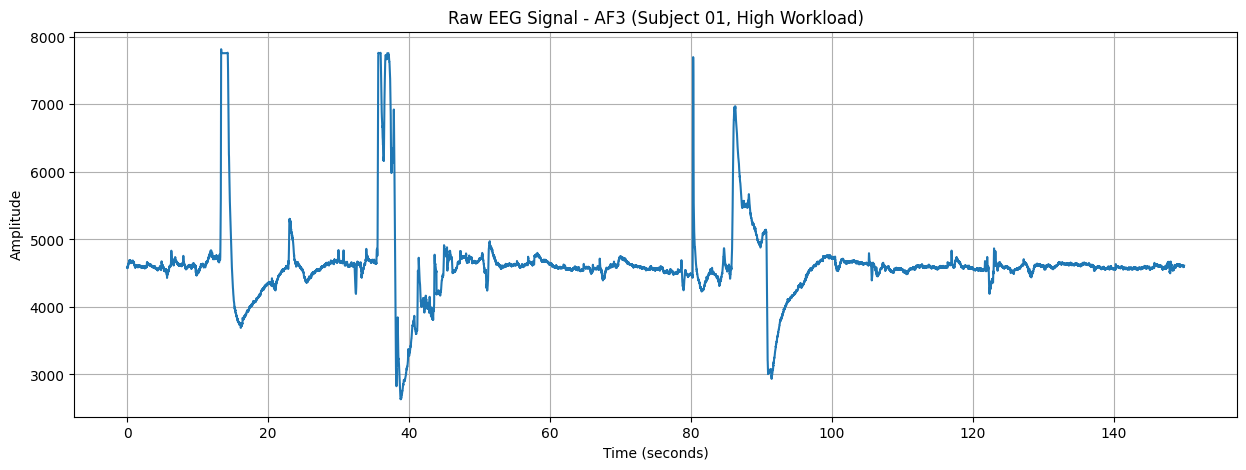

In [38]:
channel_names = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

time = np.arange(num_samples) / sampling_rate

plt.figure(figsize=(15, 5))

plt.plot(time, raw_data[:, 0])

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Raw EEG Signal - AF3 (Subject 01, High Workload)")
plt.grid(True)

plt.show()

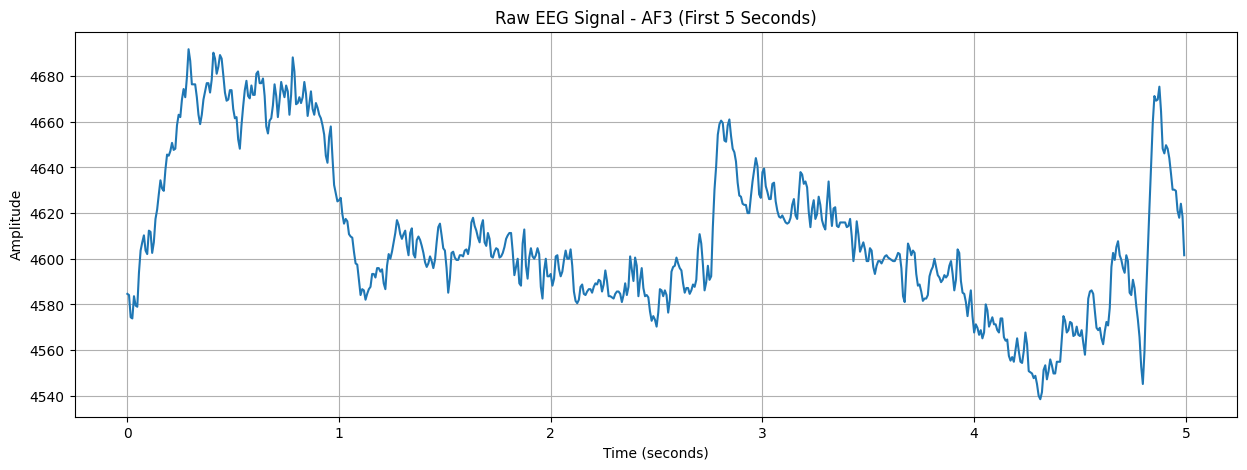

In [39]:
samples_5s = 5 * sampling_rate

plt.figure(figsize=(15, 5))

plt.plot(
    time[:samples_5s],
    raw_data[:samples_5s, 0]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Raw EEG Signal - AF3 (First 5 Seconds)")
plt.grid(True)

plt.show()

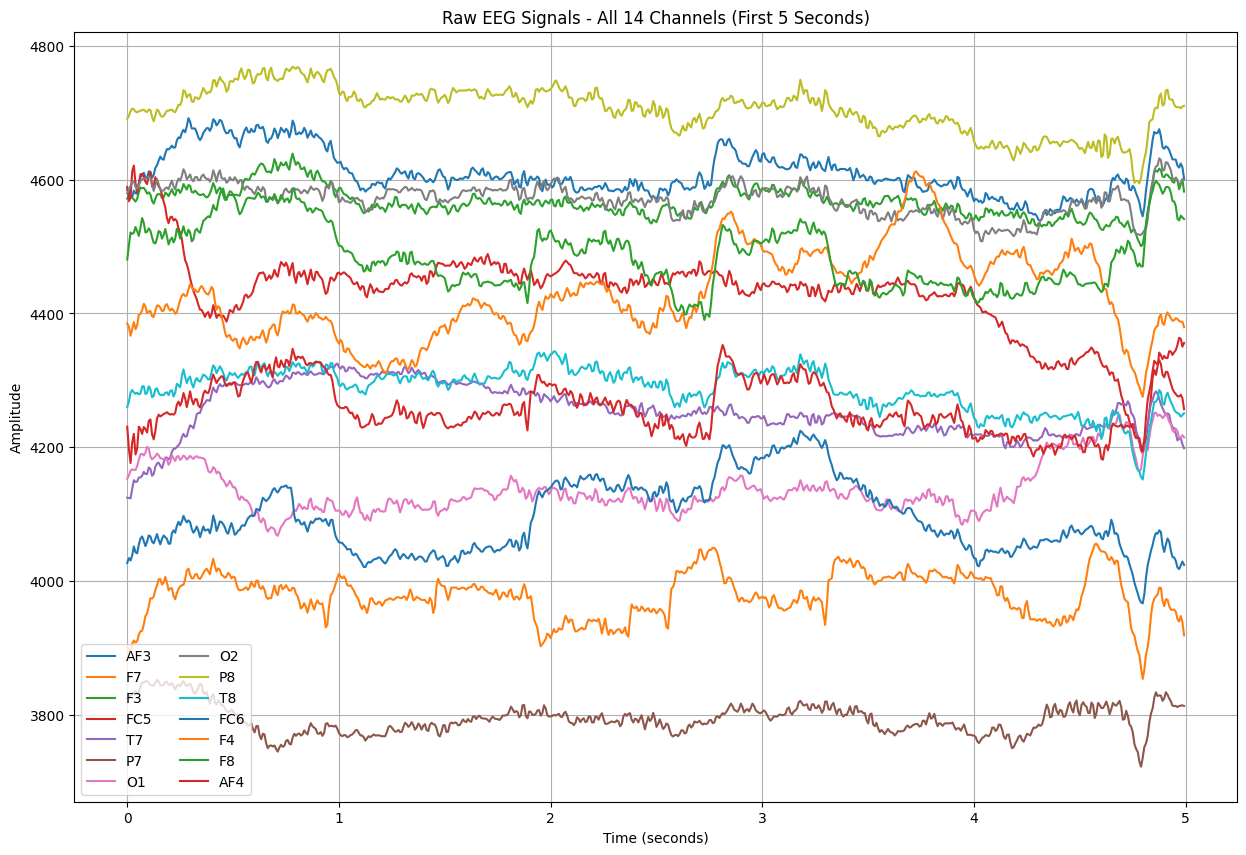

In [40]:
plt.figure(figsize=(15, 10))

for i in range(14):
    plt.plot(
        time[:samples_5s],
        raw_data[:samples_5s, i],
        label=channel_names[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Raw EEG Signals - All 14 Channels (First 5 Seconds)")
plt.legend(ncol=2)
plt.grid(True)

plt.show()

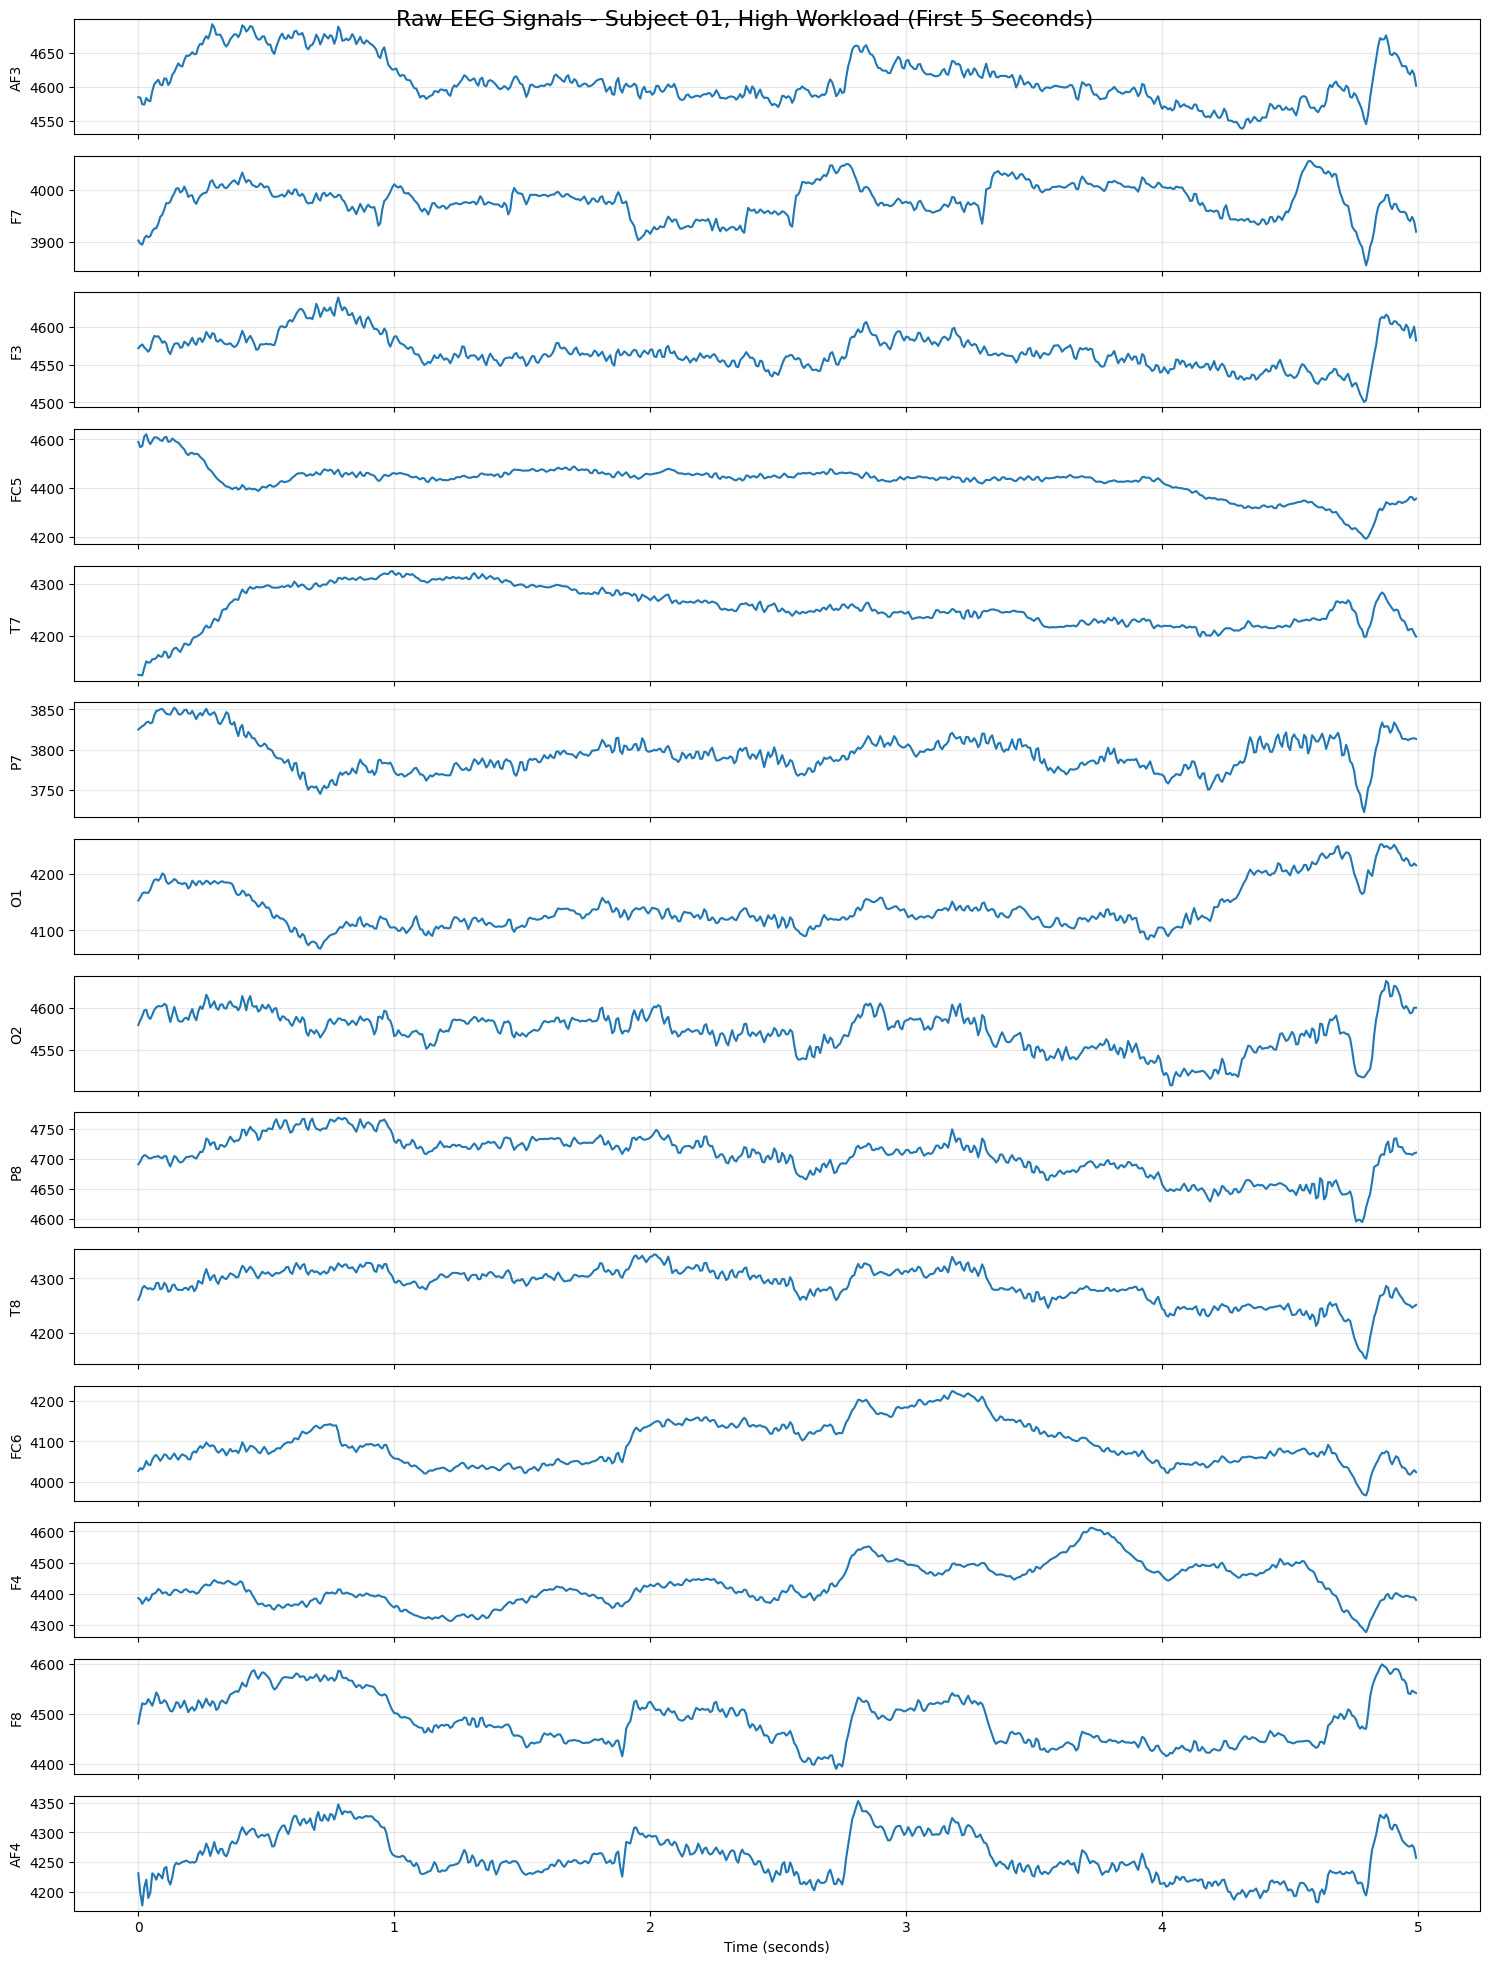

In [41]:
fig, axes = plt.subplots(14, 1, figsize=(15, 20), sharex=True)

for i in range(14):
    axes[i].plot(
        time[:samples_5s],
        raw_data[:samples_5s, i]
    )
    
    axes[i].set_ylabel(channel_names[i])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    "Raw EEG Signals - Subject 01, High Workload (First 5 Seconds)",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [42]:
for i, channel in enumerate(channel_names):
    print(
        f"{channel:4s} | "
        f"Min: {raw_data[:, i].min():.2f} | "
        f"Max: {raw_data[:, i].max():.2f} | "
        f"Mean: {raw_data[:, i].mean():.2f} | "
        f"Std: {raw_data[:, i].std():.2f}"
    )

AF3  | Min: 2633.33 | Max: 7816.41 | Mean: 4613.79 | Std: 563.34
F7   | Min: 3344.10 | Max: 7769.74 | Mean: 4025.88 | Std: 384.37
F3   | Min: 4071.28 | Max: 4825.13 | Mean: 4580.44 | Std: 68.18
FC5  | Min: 3817.44 | Max: 7535.38 | Mean: 4447.10 | Std: 267.71
T7   | Min: 3808.72 | Max: 4580.51 | Mean: 4201.44 | Std: 87.06
P7   | Min: 3021.54 | Max: 4065.64 | Mean: 3822.00 | Std: 80.97
O1   | Min: 3376.41 | Max: 4445.13 | Mean: 4142.50 | Std: 89.60
O2   | Min: 3971.28 | Max: 4812.31 | Mean: 4580.26 | Std: 68.15
P8   | Min: 4112.31 | Max: 4930.77 | Mean: 4698.50 | Std: 72.45
T8   | Min: 3656.41 | Max: 4513.33 | Mean: 4275.43 | Std: 71.15
FC6  | Min: 3488.21 | Max: 4500.00 | Mean: 4086.27 | Std: 94.95
F4   | Min: 3898.97 | Max: 5283.59 | Mean: 4450.90 | Std: 169.15
F8   | Min: 3932.31 | Max: 7791.79 | Mean: 4532.09 | Std: 358.78
AF4  | Min: 3685.13 | Max: 5355.90 | Mean: 4265.24 | Std: 108.16


In [43]:
from scipy.signal import butter, filtfilt

In [44]:
sampling_rate = 128

low_cutoff = 1
high_cutoff = 40
filter_order = 4

nyquist = sampling_rate / 2

low = low_cutoff / nyquist
high = high_cutoff / nyquist

b, a = butter(
    filter_order,
    [low, high],
    btype="bandpass"
)

print("Sampling frequency:", sampling_rate, "Hz")
print("Bandpass range:", low_cutoff, "-", high_cutoff, "Hz")
print("Filter order:", filter_order)

Sampling frequency: 128 Hz
Bandpass range: 1 - 40 Hz
Filter order: 4


In [45]:
filtered_data = filtfilt(
    b,
    a,
    raw_data,
    axis=0
)

print("Raw data shape:", raw_data.shape)
print("Filtered data shape:", filtered_data.shape)

Raw data shape: (19200, 14)
Filtered data shape: (19200, 14)


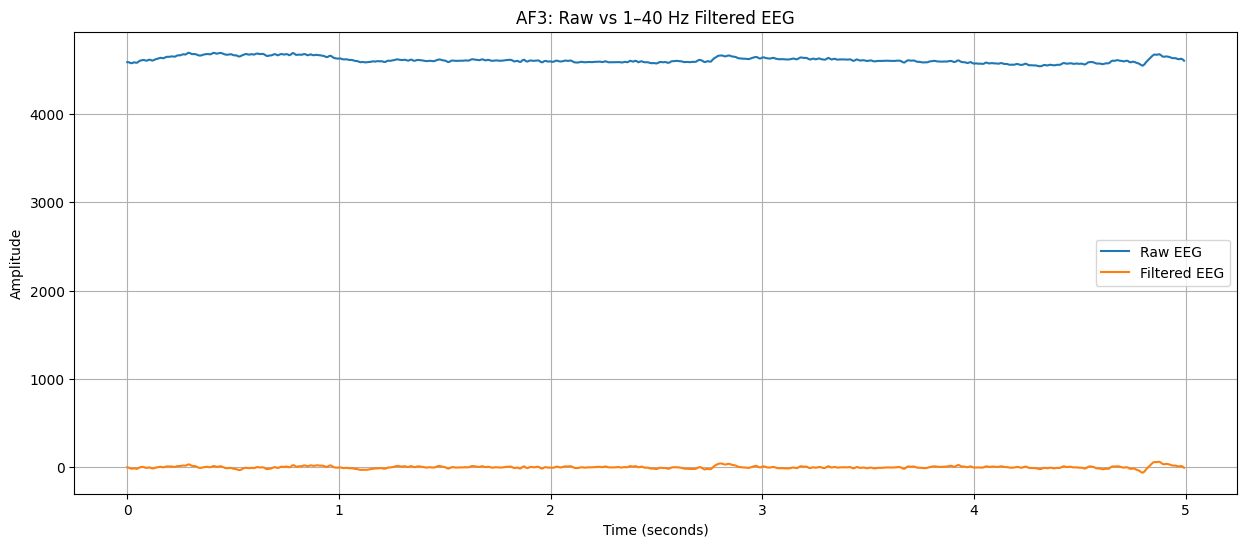

In [46]:
plt.figure(figsize=(15, 6))

plt.plot(
    time[:samples_5s],
    raw_data[:samples_5s, 0],
    label="Raw EEG"
)

plt.plot(
    time[:samples_5s],
    filtered_data[:samples_5s, 0],
    label="Filtered EEG"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("AF3: Raw vs 1–40 Hz Filtered EEG")
plt.legend()
plt.grid(True)

plt.show()

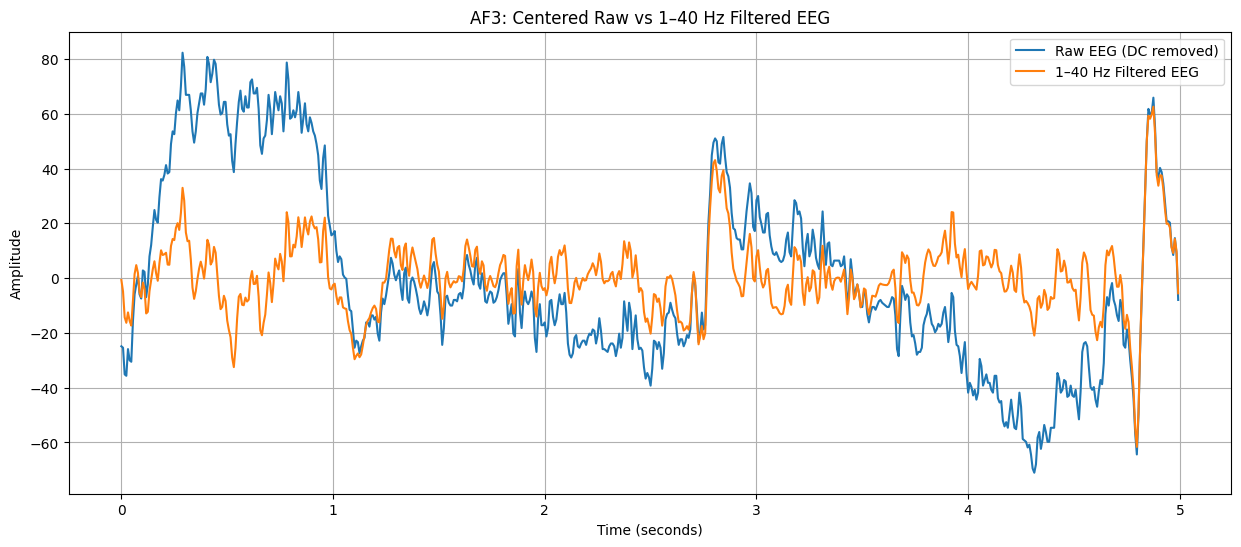

In [47]:
plt.figure(figsize=(15, 6))

plt.plot(
    time[:samples_5s],
    raw_data[:samples_5s, 0] - np.mean(raw_data[:samples_5s, 0]),
    label="Raw EEG (DC removed)"
)

plt.plot(
    time[:samples_5s],
    filtered_data[:samples_5s, 0],
    label="1–40 Hz Filtered EEG"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("AF3: Centered Raw vs 1–40 Hz Filtered EEG")
plt.legend()
plt.grid(True)

plt.show()

## 2. 50 Hz Notch Filtering

A notch filter is used to suppress power-line interference around 50 Hz.

The STEW recordings were sampled at 128 Hz, so 50 Hz lies below the Nyquist frequency of 64 Hz and can appear as electrical interference.

The notch filter is applied before the 1–40 Hz bandpass filter.

In [48]:
from scipy.signal import iirnotch

notch_frequency = 50
quality_factor = 30

b_notch, a_notch = iirnotch(
    notch_frequency,
    quality_factor,
    sampling_rate
)

notched_data = filtfilt(
    b_notch,
    a_notch,
    raw_data,
    axis=0
)

print("Notch frequency:", notch_frequency, "Hz")
print("Quality factor:", quality_factor)
print("Notched data shape:", notched_data.shape)

Notch frequency: 50 Hz
Quality factor: 30
Notched data shape: (19200, 14)


In [49]:
filtered_data = filtfilt(
    b,
    a,
    notched_data,
    axis=0
)

print(filtered_data.shape)

(19200, 14)


In [50]:
# Step 1: 50 Hz notch filtering
notched_data = filtfilt(
    b_notch,
    a_notch,
    raw_data,
    axis=0
)

# Step 2: 1–40 Hz bandpass filtering
filtered_data = filtfilt(
    b,
    a,
    notched_data,
    axis=0
)

print("Raw:", raw_data.shape)
print("After notch:", notched_data.shape)
print("After bandpass:", filtered_data.shape)

Raw: (19200, 14)
After notch: (19200, 14)
After bandpass: (19200, 14)


## 3. EEG Signal Normalization

After filtering, the EEG signals are normalized independently for each channel using z-score normalization.

For each channel:

z = (x - μ) / σ

where μ is the channel mean and σ is the channel standard deviation.

This centers each channel around zero and scales its variation to approximately unit standard deviation.

In [51]:
# Z-score normalization per EEG channel

channel_mean = np.mean(filtered_data, axis=0)
channel_std = np.std(filtered_data, axis=0)

normalized_data = (filtered_data - channel_mean) / channel_std

print("Normalized data shape:", normalized_data.shape)
print("\nMean of each channel:")
print(np.mean(normalized_data, axis=0))

print("\nStandard deviation of each channel:")
print(np.std(normalized_data, axis=0))

Normalized data shape: (19200, 14)

Mean of each channel:
[-2.25514052e-18 -1.79110199e-18 -4.65484133e-19  1.59768032e-17
  7.30029463e-18 -2.39608680e-18  2.60208521e-18  1.26801058e-17
 -5.85324613e-18  1.09171931e-17  1.91686944e-18  2.16840434e-20
 -4.56810515e-18 -8.13729871e-18]

Standard deviation of each channel:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


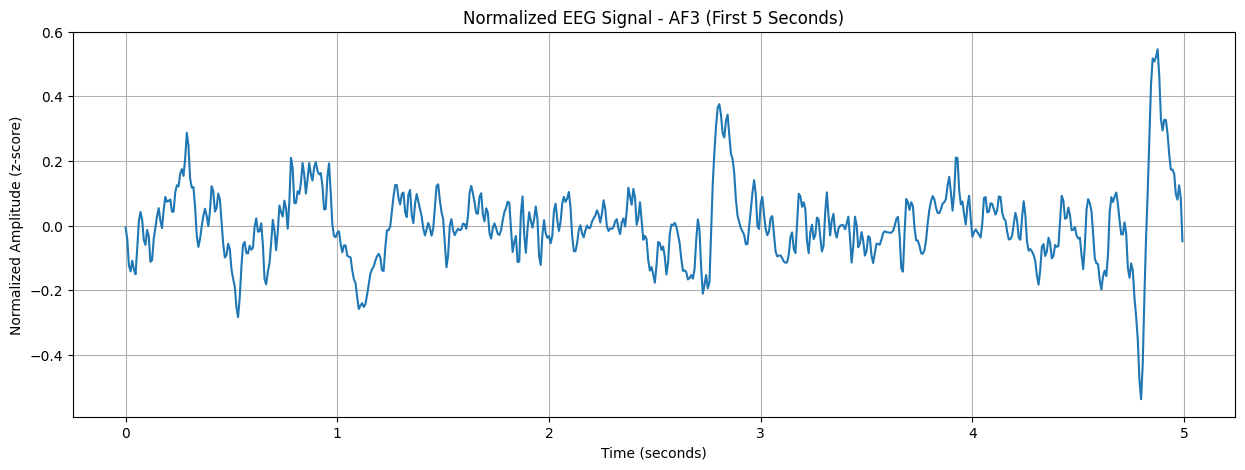

In [52]:
plt.figure(figsize=(15, 5))

plt.plot(
    time[:samples_5s],
    normalized_data[:samples_5s, 0]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude (z-score)")
plt.title("Normalized EEG Signal - AF3 (First 5 Seconds)")
plt.grid(True)

plt.show()

## 4. Workload Ratings and Labels

The STEW dataset provides a ratings file containing workload information for the subjects.

We inspect this file to understand how the high- and low-workload conditions are represented.

In [53]:
ratings_file = dataset_path / "ratings.txt"

print("Ratings file:", ratings_file)
print("Exists:", ratings_file.exists())

Ratings file: ..\STEW Dataset\ratings.txt
Exists: True


In [54]:
with open(ratings_file, "r") as f:
    for i in range(15):
        line = f.readline()
        if not line:
            break
        print(line.strip())

1, 2, 8
2, 1, 5
3, 1, 5
4, 2, 5
6, 4, 7
7, 1, 5
8, 3, 7
9, 1, 7
10, 1, 6
11, 1, 5
12, 1, 6
13, 2, 7
14, 2, 7
15, 1, 6
16, 2, 9


## 4.1 Understanding the Workload Labels

The STEW dataset contains two EEG recordings for each subject:

- `subXX_lo.txt` — EEG recorded during the low-workload/rest condition
- `subXX_hi.txt` — EEG recorded during the high-workload/SIMKAP condition

The `ratings.txt` file contains:

`subject number, rating at rest, rating during SIMKAP`

For binary workload classification, the experimental conditions are used as the primary labels:

- Low workload → 0
- High workload → 1

The numerical ratings are retained as additional metadata.

In [55]:
ratings = np.loadtxt(
    ratings_file,
    delimiter=",",
    dtype=int
)

print("Ratings shape:", ratings.shape)
print("\nFirst 10 entries:")
print(ratings[:10])

Ratings shape: (45, 3)

First 10 entries:
[[ 1  2  8]
 [ 2  1  5]
 [ 3  1  5]
 [ 4  2  5]
 [ 6  4  7]
 [ 7  1  5]
 [ 8  3  7]
 [ 9  1  7]
 [10  1  6]
 [11  1  5]]


## 4.2 Dataset Label Summary

The STEW dataset contains EEG recordings from 48 subjects.

Each subject has two EEG recordings:
- `subXX_lo.txt` → Low-workload condition → Label 0
- `subXX_hi.txt` → High-workload condition → Label 1

Therefore:
- 48 low-workload recordings
- 48 high-workload recordings
- 96 EEG recordings in total

The `ratings.txt` file contains workload ratings for 45 subjects. These ratings are retained as metadata but are not required for the primary binary classification task, since the experimental condition is indicated by the recording filename.

## 5. EEG Segmentation

The normalized EEG recordings are divided into fixed-length windows.

Parameters:
- Sampling rate: 128 Hz
- Window duration: 4 seconds
- Samples per window: 512
- Overlap: 50%
- Step size: 256 samples

Each resulting EEG segment has the shape:

`512 samples × 14 channels`

In [56]:
def segment_eeg(data, sampling_rate=128, window_seconds=4, overlap=0.5):
    """
    Segment multichannel EEG data into overlapping fixed-length windows.

    Parameters
    ----------
    data : numpy.ndarray
        EEG data with shape (samples, channels).

    sampling_rate : int
        EEG sampling frequency in Hz.

    window_seconds : int
        Length of each window in seconds.

    overlap : float
        Fraction of overlap between consecutive windows.

    Returns
    -------
    segments : numpy.ndarray
        Segmented EEG data with shape
        (num_windows, window_samples, channels).
    """

    window_samples = int(window_seconds * sampling_rate)
    step_samples = int(window_samples * (1 - overlap))

    segments = []

    for start in range(0, len(data) - window_samples + 1, step_samples):
        end = start + window_samples
        segments.append(data[start:end])

    return np.array(segments)

In [57]:
segments = segment_eeg(normalized_data)

print("Segmented data shape:", segments.shape)

Segmented data shape: (74, 512, 14)


## 6. Complete EEG Preprocessing Pipeline

For each STEW recording, the preprocessing pipeline performs:

1. Load raw EEG data
2. Apply 50 Hz notch filtering
3. Apply 1–40 Hz bandpass filtering
4. Perform per-channel z-score normalization
5. Segment the EEG into 4-second windows with 50% overlap

Each processed recording produces EEG windows of shape `512 × 14`.

In [69]:
def preprocess_eeg(file_path):
    """
    Preprocess one STEW EEG recording.

    Steps:
    1. Load raw EEG
    2. 50 Hz notch filtering
    3. 1–40 Hz bandpass filtering
    4. Segment into 4-second windows with 50% overlap

    Normalization is performed later using training-set statistics
    to avoid data leakage.
    """

    # 1. Load raw EEG
    data = np.loadtxt(file_path)

    # 2. 50 Hz notch filter
    notched_data = filtfilt(
        b_notch,
        a_notch,
        data,
        axis=0
    )

    # 3. 1–40 Hz bandpass filter
    filtered_data = filtfilt(
        b,
        a,
        notched_data,
        axis=0
    )

    # 4. Segment
    segments = segment_eeg(
        filtered_data,
        sampling_rate=128,
        window_seconds=4,
        overlap=0.5
    )

    return segments

In [70]:
all_segments = []
all_labels = []
metadata = []

for file in eeg_files:

    # Filter + segment
    segments = preprocess_eeg(file)

    # Assign label
    if "_hi" in file.stem:
        label = 1
        condition = "high"

    elif "_lo" in file.stem:
        label = 0
        condition = "low"

    else:
        continue

    # Extract subject number
    subject = int(file.stem[3:5])

    # Store every window
    for window_index, segment in enumerate(segments):

        all_segments.append(segment)
        all_labels.append(label)

        metadata.append({
            "subject": subject,
            "condition": condition,
            "label": label,
            "window": window_index
        })

print("Processing complete.")

Processing complete.


In [71]:
X_filtered = np.array(all_segments, dtype=np.float32)
y = np.array(all_labels, dtype=np.int64)

metadata_df = pd.DataFrame(metadata)

print("X_filtered shape:", X_filtered.shape)
print("y shape:", y.shape)
print("Metadata shape:", metadata_df.shape)

X_filtered shape: (7104, 512, 14)
y shape: (7104,)
Metadata shape: (7104, 4)


In [72]:
print(metadata_df["condition"].value_counts())
print()
print(metadata_df["label"].value_counts())

condition
high    3552
low     3552
Name: count, dtype: int64

label
1    3552
0    3552
Name: count, dtype: int64


In [73]:
from sklearn.model_selection import train_test_split

subjects = metadata_df["subject"].unique()

train_subjects, test_subjects = train_test_split(
    subjects,
    test_size=0.20,
    random_state=42
)

print("Number of training subjects:", len(train_subjects))
print("Number of testing subjects:", len(test_subjects))

print("\nTraining subjects:")
print(sorted(train_subjects))

print("\nTesting subjects:")
print(sorted(test_subjects))

Number of training subjects: 38
Number of testing subjects: 10

Training subjects:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(39), np.int64(40), np.int64(42), np.int64(43), np.int64(45), np.int64(46), np.int64(47), np.int64(48)]

Testing subjects:
[np.int64(5), np.int64(13), np.int64(20), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(38), np.int64(41), np.int64(44)]


In [74]:
train_mask = metadata_df["subject"].isin(train_subjects)
test_mask = metadata_df["subject"].isin(test_subjects)

X_train = X_filtered[train_mask.values]
X_test = X_filtered[test_mask.values]

y_train = y[train_mask.values]
y_test = y[test_mask.values]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5624, 512, 14)
X_test: (1480, 512, 14)
y_train: (5624,)
y_test: (1480,)


In [75]:
# Find all EEG recordings

eeg_files = sorted(dataset_path.glob("sub*.txt"))

print("Total EEG files:", len(eeg_files))
print("\nFirst 10 files:")

for file in eeg_files[:10]:
    print(file.name)

Total EEG files: 96

First 10 files:
sub01_hi.txt
sub01_lo.txt
sub02_hi.txt
sub02_lo.txt
sub03_hi.txt
sub03_lo.txt
sub04_hi.txt
sub04_lo.txt
sub05_hi.txt
sub05_lo.txt


processed_path = Path("../processed_data")
processed_path.mkdir(exist_ok=True)

np.save(processed_path / "X.npy", X)
np.save(processed_path / "y.npy", y)

metadata_df.to_csv(
    processed_path / "metadata.csv",
    index=False
)

print("Processed dataset saved successfully.")

## 10. Train-Set Based EEG Normalization

To avoid data leakage, normalization parameters are calculated using only the training subjects.

The training mean and standard deviation are then applied to both the training and testing data.

In [76]:
# Calculate normalization parameters using TRAINING data only

train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True)

print("Training mean shape:", train_mean.shape)
print("Training std shape:", train_std.shape)

Training mean shape: (1, 1, 14)
Training std shape: (1, 1, 14)


In [77]:
X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("X_train_norm:", X_train_norm.shape)
print("X_test_norm:", X_test_norm.shape)

X_train_norm: (5624, 512, 14)
X_test_norm: (1480, 512, 14)


In [78]:
print("Training normalized mean:")
print(X_train_norm.mean(axis=(0, 1)))

print("\nTraining normalized std:")
print(X_train_norm.std(axis=(0, 1)))

Training normalized mean:
[-7.0283126e-09 -1.4278323e-09 -3.3213829e-10  8.2493754e-09
 -7.0074058e-09 -2.5196250e-09 -3.1743927e-09  5.8902527e-10
 -4.1164392e-09  1.1399280e-09 -9.8348074e-10  9.8169046e-09
 -3.8238781e-09 -4.2298760e-09]

Training normalized std:
[0.9997259  1.0004346  0.9996204  1.0006552  1.0000478  0.99932283
 1.0004271  1.0003859  1.0010018  0.9992162  0.99959105 0.9998579
 1.0002587  0.99987334]


In [79]:
print("Test normalized mean:")
print(X_test_norm.mean(axis=(0, 1)))

print("\nTest normalized std:")
print(X_test_norm.std(axis=(0, 1)))

Test normalized mean:
[ 4.8181333e-05 -1.5361824e-05 -5.2658444e-05  4.6274799e-05
 -2.4858399e-04 -1.3056383e-04  6.5289853e-05 -5.0052033e-05
 -2.0276482e-04 -8.0661295e-05  1.0233517e-06 -1.4106427e-04
  1.1477492e-05  3.2002368e-05]

Test normalized std:
[1.0416307 1.2170513 1.825537  1.4525576 0.3579141 2.780757  2.5143783
 2.5041227 2.1516044 1.8696232 2.1452699 1.8611214 1.4373488 1.6593807]


In [80]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training class distribution:
0    2812
1    2812
Name: count, dtype: int64

Testing class distribution:
0    740
1    740
Name: count, dtype: int64


In [81]:
final_processed_path = Path("../processed_data")
final_processed_path.mkdir(exist_ok=True)

# Save final normalized datasets
np.save(final_processed_path / "X_train.npy", X_train_norm.astype(np.float32))
np.save(final_processed_path / "X_test.npy", X_test_norm.astype(np.float32))

np.save(final_processed_path / "y_train.npy", y_train)
np.save(final_processed_path / "y_test.npy", y_test)

# Save subject information
train_metadata = metadata_df[train_mask].copy()
test_metadata = metadata_df[test_mask].copy()

train_metadata.to_csv(
    final_processed_path / "train_metadata.csv",
    index=False
)

test_metadata.to_csv(
    final_processed_path / "test_metadata.csv",
    index=False
)

# Save normalization parameters
np.save(final_processed_path / "train_mean.npy", train_mean)
np.save(final_processed_path / "train_std.npy", train_std)

print("Final processed datasets saved successfully.")

Final processed datasets saved successfully.


In [83]:
from pathlib import Path

preprocessing_folder = Path("../preprocessing").resolve()

print("Preprocessing folder:")
print(preprocessing_folder)

print("\nFolder exists:", preprocessing_folder.exists())

print("\nFiles inside:")
if preprocessing_folder.exists():
    for file in preprocessing_folder.iterdir():
        print(file.name)

Preprocessing folder:
C:\Users\imman\OneDrive\Desktop\FYP\preprocessing

Folder exists: True

Files inside:


In [84]:
from pathlib import Path

preprocessing_folder = Path("../preprocessing").resolve()

print("Preprocessing folder:")
print(preprocessing_folder)

print("\nFolder exists:", preprocessing_folder.exists())

print("\nFiles inside:")
for file in preprocessing_folder.iterdir():
    print(file.name)

Preprocessing folder:
C:\Users\imman\OneDrive\Desktop\FYP\preprocessing

Folder exists: True

Files inside:
preprocessing.py


In [85]:
import sys
sys.path.insert(0, str(preprocessing_folder))

from preprocessing import preprocess_eeg

print("Import successful!")

Import successful!


In [86]:
test_segments = preprocess_eeg(
    dataset_path / "sub01_hi.txt"
)

print("Test output shape:", test_segments.shape)

Test output shape: (74, 512, 14)
